In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from sklearn.model_selection import train_test_split
from pathlib import Path

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [2]:
DATA_DIR = Path.home()/"Downloads"/"archive"/"dataset"   

IMG_SIZE = 224
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

train_transform = eval_transform

train_base = datasets.ImageFolder(DATA_DIR, transform=train_transform)
eval_base = datasets.ImageFolder(DATA_DIR, transform=eval_transform)

class_names = eval_base.classes
labels = eval_base.targets

idx_train, idx_rest = train_test_split(
    list(range(len(labels))), test_size=0.30, random_state=42, stratify=labels)
idx_val, idx_test = train_test_split(
    idx_rest, test_size=0.50, random_state=42, stratify=[labels[i] for i in idx_rest])

train_ds = Subset(train_base, idx_train)
val_ds = Subset(eval_base, idx_val)
test_ds = Subset(eval_base, idx_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

print(f"{len(class_names)} classes: {class_names}")
print(f"{len(labels)} images total -> train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}")

print(f"\n{'breed':<20}{'train':>7}{'val':>6}{'test':>6}")
for c, name in enumerate(class_names):
    row = [sum(1 for i in idx if labels[i] == c) for idx in (idx_train, idx_val, idx_test)]
    print(f"{name:<20}{row[0]:>7}{row[1]:>6}{row[2]:>6}")

assert not (set(idx_train) & set(idx_val) & set(idx_test))
assert len(set(idx_train) | set(idx_val) | set(idx_test)) == len(labels)

10 classes: ['Beagle', 'Boxer', 'Bulldog', 'Dachshund', 'German_Shepherd', 'Golden_Retriever', 'Labrador_Retriever', 'Poodle', 'Rottweiler', 'Yorkshire_Terrier']
967 images total -> train 676 | val 145 | test 146

breed                 train   val  test
Beagle                   70    15    15
Boxer                    70    15    15
Bulldog                  70    15    15
Dachshund                67    14    15
German_Shepherd          67    14    15
Golden_Retriever         64    14    13
Labrador_Retriever       66    14    15
Poodle                   70    15    15
Rottweiler               62    14    13
Yorkshire_Terrier        70    15    15


In [3]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

print(f"Replaced the final layer -> {len(class_names)} classes")

Replaced the final layer -> 10 classes


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
EPOCHS = 5


@torch.no_grad()
def accuracy(loader):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total


best_acc, best_epoch, best_state = -1.0, 0, None

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * y.size(0)

    train_loss = running / len(train_ds)
    val_acc = accuracy(val_loader)

    mark = ""
    if val_acc > best_acc:
        best_acc, best_epoch = val_acc, epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        mark = "  <- best so far"
    print(f"epoch {epoch}/{EPOCHS}  train loss = {train_loss:.4f}  val accuracy = {val_acc:.3f}{mark}")

model.load_state_dict(best_state) 

torch.save({
    "model_state": best_state,
    "class_names": class_names,
    "arch": "resnet18",
    "img_size": IMG_SIZE,
    "norm_mean": NORM_MEAN,
    "norm_std": NORM_STD,
    "val_accuracy": best_acc,
    "epoch": best_epoch,
}, "simple_model.pth")

print(f"\nSaved epoch {best_epoch} (val accuracy {best_acc:.3f}) to simple_model.pth")

epoch 1/5  train loss = 1.9548  val accuracy = 0.110  <- best so far
epoch 2/5  train loss = 0.8180  val accuracy = 0.897  <- best so far
epoch 3/5  train loss = 0.1768  val accuracy = 0.993  <- best so far
epoch 4/5  train loss = 0.0755  val accuracy = 0.993
epoch 5/5  train loss = 0.0338  val accuracy = 0.986

Saved epoch 3 (val accuracy 0.993) to simple_model.pth


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8606442..2.64].


y_true: [4]  y_pred: [2]


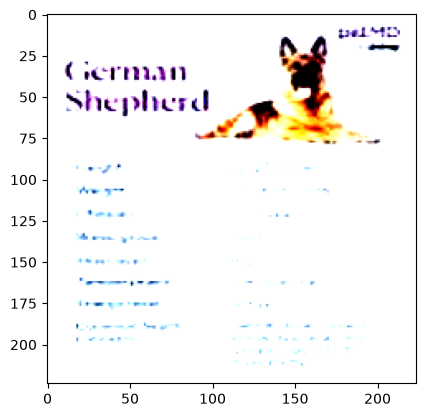

In [5]:
import matplotlib.pyplot as plt
model.eval()
test_loader = DataLoader(test_ds, batch_size=1)
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        pred= model(x.to(device)).argmax(1).cpu()
        if pred != y.cpu():
            print(f"y_true: {y.cpu().numpy()}  y_pred: {pred.numpy()}")
            plt.imshow(x[0].cpu().permute(1, 2, 0))
            plt.show()

val  accuracy = 0.993  (used to pick the epoch - optimistically biased)
test accuracy = 0.993  (the number to report)
1 wrong out of 146 images

                    precision    recall  f1-score   support

            Beagle      1.000     1.000     1.000        15
             Boxer      1.000     1.000     1.000        15
           Bulldog      0.938     1.000     0.968        15
         Dachshund      1.000     1.000     1.000        15
   German_Shepherd      1.000     0.933     0.966        15
  Golden_Retriever      1.000     1.000     1.000        13
Labrador_Retriever      1.000     1.000     1.000        15
            Poodle      1.000     1.000     1.000        15
        Rottweiler      1.000     1.000     1.000        13
 Yorkshire_Terrier      1.000     1.000     1.000        15

          accuracy                          0.993       146
         macro avg      0.994     0.993     0.993       146
      weighted avg      0.994     0.993     0.993       146



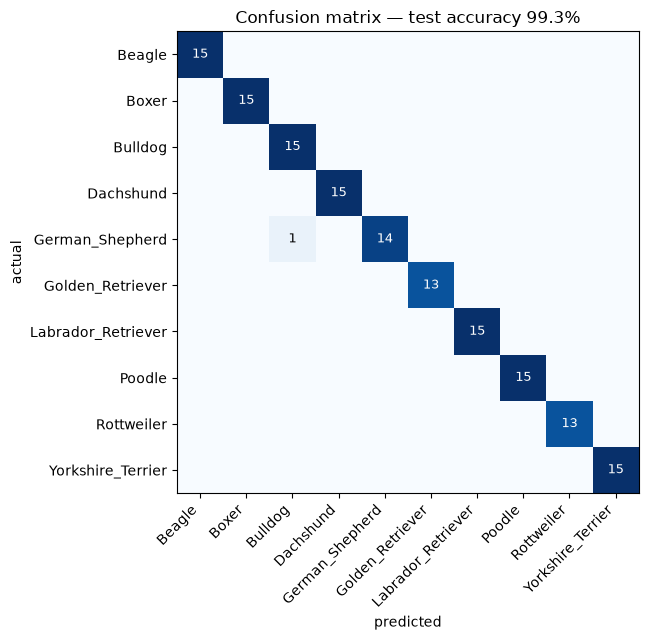

Most confused pairs (actual -> predicted):
  German_Shepherd -> Bulldog  1 images


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix


@torch.no_grad()
def collect(loader):
    model.eval()
    ys, preds = [], []
    for x, y in loader:
        preds.append(model(x.to(device)).argmax(1).cpu())
        ys.append(y)
    return torch.cat(ys).numpy(), torch.cat(preds).numpy()


y_true, y_pred = collect(test_loader)
test_acc = (y_true == y_pred).mean()

print(f"val  accuracy = {best_acc:.3f}  (used to pick the epoch - optimistically biased)")
print(f"test accuracy = {test_acc:.3f}  (the number to report)")
print(f"{int((y_true != y_pred).sum())} wrong out of {len(y_true)} images\n")

print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)), class_names, rotation=45, ha="right")
ax.set_yticks(range(len(class_names)), class_names)
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title(f"Confusion matrix — test accuracy {test_acc:.1%}")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

mistakes = [(cm[i, j], class_names[i], class_names[j])
            for i in range(len(class_names)) for j in range(len(class_names)) if i != j and cm[i, j]]
if mistakes:
    print("Most confused pairs (actual -> predicted):")
    for n, a, b in sorted(mistakes, reverse=True)[:5]:
        print(f"  {a} -> {b}  {n} images")
    

else:
    print("No misclassified images in the test set")

In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import models, transforms
from PIL import Image, ImageOps
from pathlib import Path

CKPT_PATH = "simple_model.pth"


def load_model(path=CKPT_PATH):
    ckpt = torch.load(path, map_location="cpu", weights_only=True)
    names = ckpt["class_names"]

    net = models.resnet18()                                   
    net.fc = nn.Linear(net.fc.in_features, len(names))        
    net.load_state_dict(ckpt["model_state"])                

    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net.to(dev).eval()

    tf = transforms.Compose([
        transforms.Resize((ckpt["img_size"], ckpt["img_size"])),
        transforms.ToTensor(),
        transforms.Normalize(ckpt["norm_mean"], ckpt["norm_std"]),
    ])
    return net, tf, names, dev, ckpt


net, tf, names, dev, ckpt = load_model()

print(f"Loaded the model from {CKPT_PATH}")
print(f"  architecture : {ckpt.get('arch', 'resnet18')}")
print(f"  {len(names)} classes   : {names}")
print(f"  trained to   : epoch {ckpt.get('epoch', '?')} (val accuracy {ckpt.get('val_accuracy', float('nan')):.3f})")
print(f"  preprocessing: resize {ckpt['img_size']}x{ckpt['img_size']} + normalize")
print(f"  predicting on: {dev}")

Loaded the model from simple_model.pth
  architecture : resnet18
  10 classes   : ['Beagle', 'Boxer', 'Bulldog', 'Dachshund', 'German_Shepherd', 'Golden_Retriever', 'Labrador_Retriever', 'Poodle', 'Rottweiler', 'Yorkshire_Terrier']
  trained to   : epoch 3 (val accuracy 0.993)
  preprocessing: resize 224x224 + normalize
  predicting on: cuda


In [8]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
CONF_WARN = 0.60      


def _open(path):
    return ImageOps.exif_transpose(Image.open(path)).convert("RGB")


@torch.no_grad()
def predict(image_path, topk=3):
    """Return [(breed name, probability), ...] sorted from most to least likely."""
    x = tf(_open(image_path)).unsqueeze(0).to(dev)
    probs = torch.softmax(net(x), dim=1)[0]
    p, i = probs.topk(min(topk, len(names)))
    return [(names[c], v.item()) for v, c in zip(p, i)]


def show(image_path, topk=3):
    """Show the image with the top prediction and the runners-up."""
    top = predict(image_path, topk)
    name, conf = top[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(_open(image_path))
    plt.axis("off")
    plt.title(f"{name}  ({conf:.1%})" + ("  [low confidence]" if conf < CONF_WARN else ""))
    plt.show()

    for n, c in top:
        print(f"  {n:<20} {c:6.1%}  {'█' * int(c * 30)}")
    return top


@torch.no_grad()
def predict_folder(folder, batch_size=32, preview=8):
    """Predict every image in a folder (subfolders included); returns a list of (path, name, confidence)."""
    paths = [p for p in sorted(Path(folder).rglob("*")) if p.suffix.lower() in IMG_EXT]
    if not paths:
        print(f"No image files found in {folder}")
        return []

    results, skipped = [], []
    for s in range(0, len(paths), batch_size):
        chunk, tensors = [], []
        for p in paths[s:s + batch_size]:
            try:
                tensors.append(tf(_open(p)))
                chunk.append(p)
            except Exception as e:
                skipped.append((p, type(e).__name__))

        if not tensors:
            continue
        probs = torch.softmax(net(torch.stack(tensors).to(dev)), dim=1)
        conf, idx = probs.max(1)
        results += [(p, names[c], v.item()) for p, c, v in zip(chunk, idx.tolist(), conf)]

    print(f"Predicted {len(results)} images from {folder}")
    if skipped:
        print(f"Skipped {len(skipped)} unreadable files: {[p.name for p, _ in skipped[:5]]}")

    from collections import Counter
    print(f"\n{'breed':<20}{'count':>7}{'avg confidence':>16}")
    for name, n in Counter(r[1] for r in results).most_common():
        avg = sum(r[2] for r in results if r[1] == name) / n
        print(f"{name:<20}{n:>7}{avg:>16.1%}")

    unsure = [r for r in results if r[2] < CONF_WARN]
    if unsure:
        print(f"\n⚠️  {len(unsure)} images below {CONF_WARN:.0%} confidence - worth checking by eye:")
        for p, name, c in sorted(unsure, key=lambda r: r[2])[:10]:
            print(f"  {p.name:<35} -> {name} ({c:.1%})")

    if preview:
        sample = results[:preview]
        cols = min(4, len(sample))
        rows = (len(sample) + cols - 1) // cols
        fig, _ = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.4 * rows))
        for ax, (p, name, c) in zip(fig.axes, sample):     # fig.axes is already a flat list, no numpy needed
            ax.imshow(_open(p))
            ax.axis("off")
            ax.set_title(f"{name}\n{c:.1%}", fontsize=9,
                         color="tab:red" if c < CONF_WARN else "black")
        for ax in fig.axes[len(sample):]:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    return results


print("Ready to use:  predict(path)  |  show(path)  |  predict_folder(dir)")

Ready to use:  predict(path)  |  show(path)  |  predict_folder(dir)


Predicted 1 images from C:\Users\Lenovo\Downloads\new_dogs

breed                 count  avg confidence
Rottweiler                1           91.1%


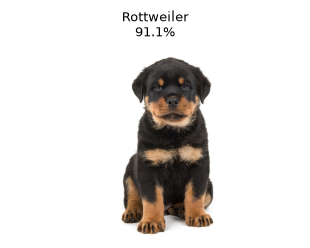

In [9]:
NEW_DIR = Path.home() / "Downloads" / "new_dogs"     # <- drop new images here
NEW_DIR.mkdir(parents=True, exist_ok=True)

has_new = any(p.suffix.lower() in IMG_EXT for p in NEW_DIR.rglob("*"))

if has_new:
    results = predict_folder(NEW_DIR)
else:
    print(f"No images in {NEW_DIR} yet")
    print("Drop some images there and re-run this cell. In the meantime, trying one image from the original dataset.\n")
    sample = next(p for p in (Path.home() / "Downloads" / "archive" / "dataset").rglob("*")
                  if p.suffix.lower() in IMG_EXT)
    print(f"Test image: {sample.parent.name}/{sample.name}  (ground truth = {sample.parent.name})")
    show(sample)